Purpose: Convert data → business insights
Sections:
🔹 Churn Drivers

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("../data/processed/segmented_data.csv")


In [3]:

df.groupby("segment_label")[[
        "Churned",
        "engagement_index",
        "value_score",
        "risk_score"
    ]].mean()



,Churned,engagement_index,value_score,risk_score
segment_label,,,,
At Risk,0.459753,18.638528,696.463054,46.850292
Loyal,0.316343,28.409478,1253.505540,22.073155
Needs Attention,0.237606,15.544896,516.520577,27.254780


🔹 Revenue at Risk

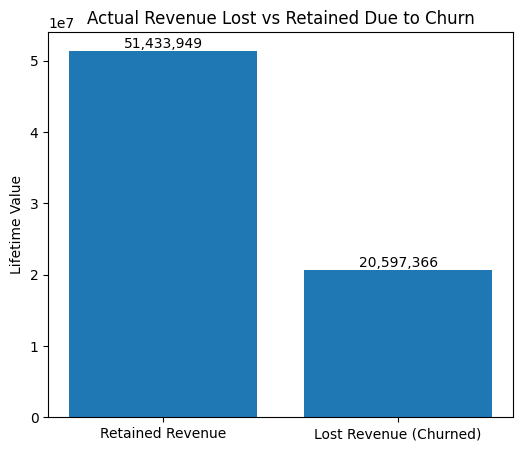

In [4]:
total_revenue = df["Lifetime_Value"].sum()
lost_revenue = df.loc[df["Churned"] == 1, "Lifetime_Value"].sum()
retained_revenue = total_revenue - lost_revenue

revenue_df = pd.DataFrame({
    "Type": ["Retained Revenue", "Lost Revenue (Churned)"],
    "Revenue": [retained_revenue, lost_revenue]
})

plt.figure(figsize=(6,5))
bars = plt.bar(revenue_df["Type"], revenue_df["Revenue"])

plt.title("Actual Revenue Lost vs Retained Due to Churn")
plt.ylabel("Lifetime Value")

for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        height,
        f"{height:,.0f}",
        ha="center",
        va="bottom"
    )

plt.show()




Segment Risk

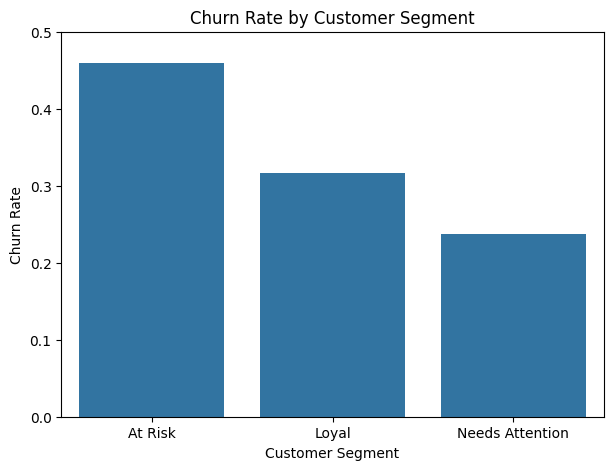

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns

churn_rate = (
    df.groupby("segment_label")["Churned"]
    .mean()
    .reset_index()
)

plt.figure(figsize=(7,5))
sns.barplot(
    x="segment_label",
    y="Churned",
    data=churn_rate
)

plt.title("Churn Rate by Customer Segment")
plt.xlabel("Customer Segment")
plt.ylabel("Churn Rate")
plt.ylim(0, 0.5)
plt.show()


🔹 Country Risk

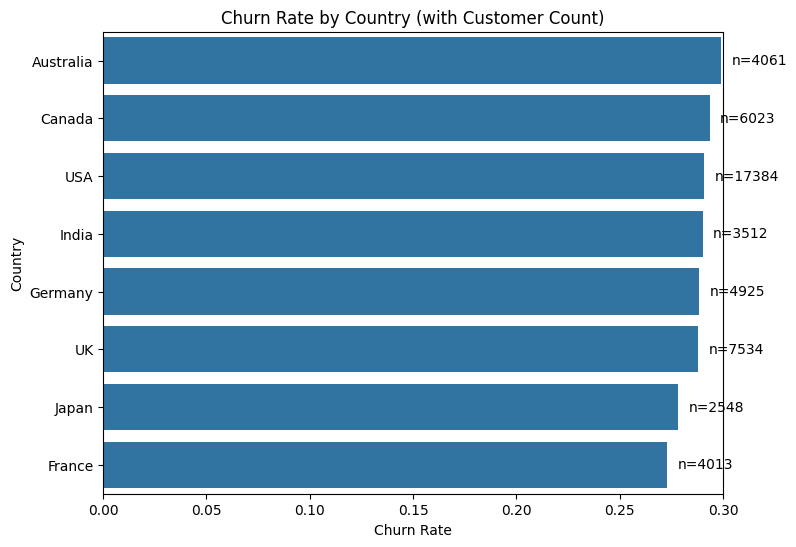

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns

country_churn = (
    df.groupby("Country")["Churned"]
    .mean()
    .sort_values(ascending=False)
    .reset_index()
)
country_summary = (
    df.groupby("Country")
    .agg(
        churn_rate=("Churned", "mean"),
        customers=("Churned", "count")
    )
    .sort_values("churn_rate", ascending=False)
)


plt.figure(figsize=(8,6))
ax = sns.barplot(
    y="Country",
    x="churn_rate",
    data=country_summary.reset_index()
)

for i, row in country_summary.reset_index().iterrows():
    ax.text(
        row["churn_rate"] + 0.005,
        i,
        f'n={row["customers"]}',
        va="center"
    )

plt.title("Churn Rate by Country (with Customer Count)")
plt.xlabel("Churn Rate")
plt.ylabel("Country")
plt.xlim(0, 0.3)
plt.show()


Revenue at risk by segment

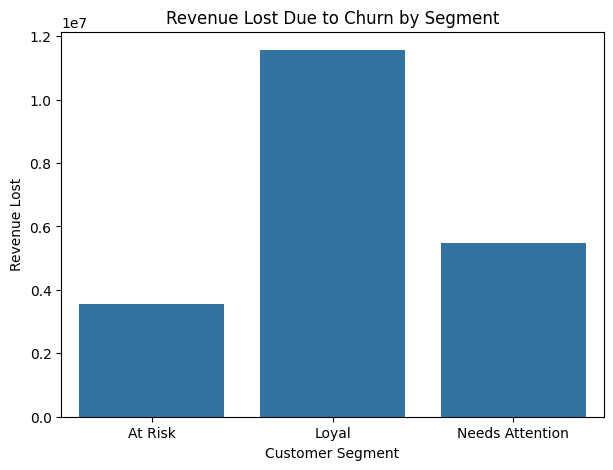

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns

lost_revenue = (
    df[df["Churned"] == 1]
    .groupby("segment_label")["Lifetime_Value"]
    .sum()
    .reset_index()
)

plt.figure(figsize=(7,5))
sns.barplot(
    x="segment_label",
    y="Lifetime_Value",
    data=lost_revenue
)


plt.title("Revenue Lost Due to Churn by Segment")
plt.xlabel("Customer Segment")
plt.ylabel("Revenue Lost")
plt.show()


4️⃣ Retention priority score (EXTREMELY valuable)

In [8]:
segment_priority = (
    df.groupby("segment_label")["retention_priority"]
    .sum()
    .reset_index()
)

plt.figure(figsize=(7,5))
sns.barplot(
    x="segment_label",
    y="retention_priority",
    data=segment_priority
)

plt.title("Total Retention Priority by Segment")
plt.xlabel("Customer Segment")
plt.ylabel("Retention Priority Score")
plt.show()


KeyError: 'Column not found: retention_priority'